In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
low_path = "LOL-v2/synthetic/train/low"
high_path = "LOL-v2/synthetic/train/normal"

In [3]:
image_names = os.listdir(low_path)

print("Number of images:", len(image_names))
print(image_names[:10])

Number of images: 900
['r17fe8532t.png', 'r0648cff8t.png', 'r1c243af7t.png', 'r1800ab47t.png', 'r09d5cb41t.png', 'r0eedd456t.png', 'r0438eb97t.png', 'r04e19833t.png', 'r1e367d35t.png', 'r1d1d501et.png']


In [4]:
image_name = image_names[5]

print(image_name)

r0eedd456t.png


In [5]:
low_img = cv2.imread(os.path.join(low_path, image_name))
high_img = cv2.imread(os.path.join(high_path, image_name))

In [6]:
low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)

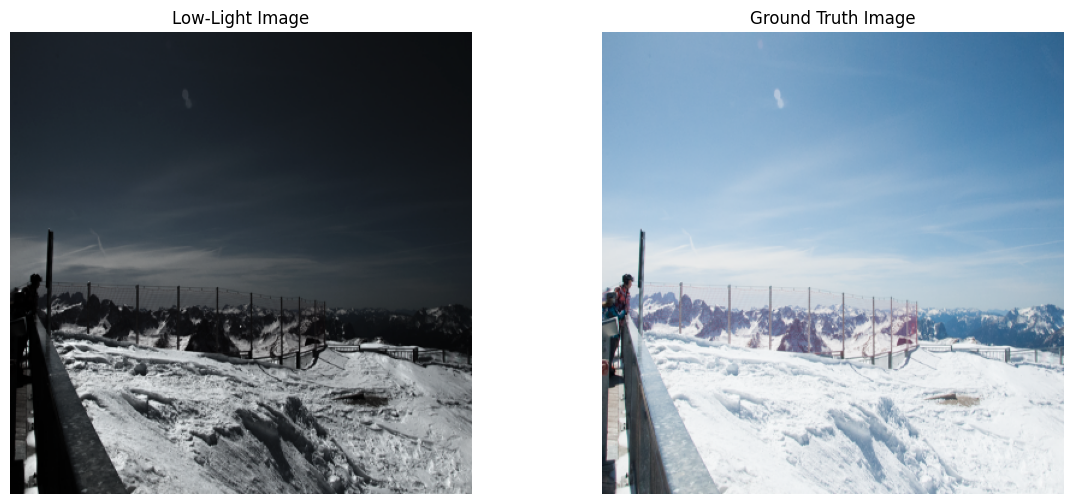

In [7]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(low_img)
plt.title("Low-Light Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(high_img)
plt.title("Ground Truth Image")
plt.axis("off")

plt.show()

In [8]:
print(low_img[100,100])

[34 45 54]


In [9]:
print(high_img[100,100])

[145 182 213]


In [10]:
#  Gray = 0.299R + 0.587G + 0.114B

#  Human eyes are more sensitive to green.

In [11]:
gray_low = cv2.cvtColor(low_img, cv2.COLOR_RGB2GRAY)
gray_high = cv2.cvtColor(high_img, cv2.COLOR_RGB2GRAY)

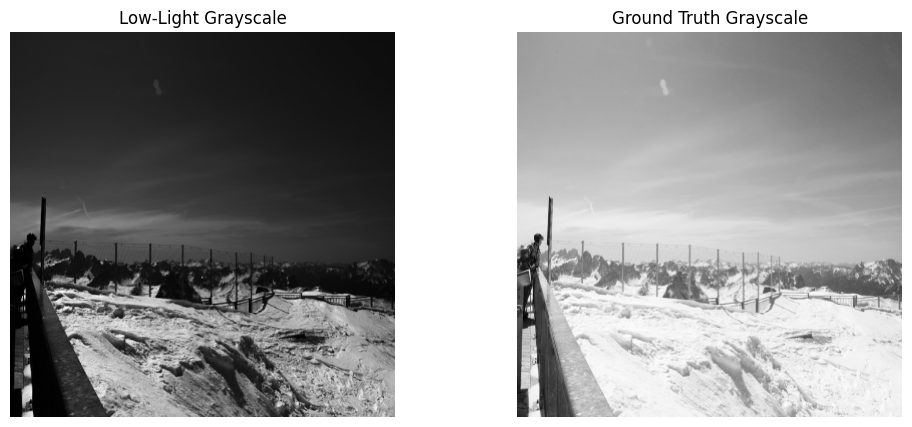

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gray_low, cmap='gray')
plt.title("Low-Light Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray_high, cmap='gray')
plt.title("Ground Truth Grayscale")
plt.axis("off")

plt.show()

In [13]:
# histogram

# how many pixels exist at each brightness level

# 0   → black
# 255 → white

In [14]:
hist = cv2.calcHist(
    [gray_low],
    [0],
    None,
    [256],
    [0,256]
)

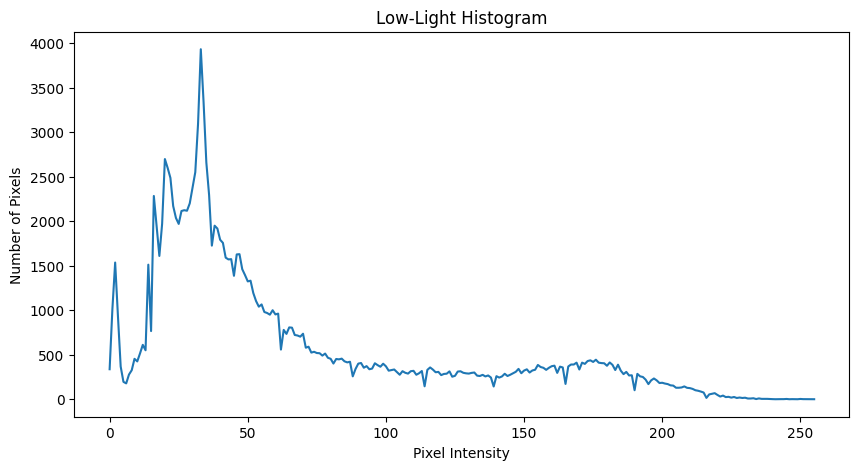

In [15]:
plt.figure(figsize=(10,5))

plt.plot(hist)

plt.title("Low-Light Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

plt.show()

In [16]:
hist = cv2.calcHist(
    [gray_high],
    [0],
    None,
    [256],
    [0,256]
)

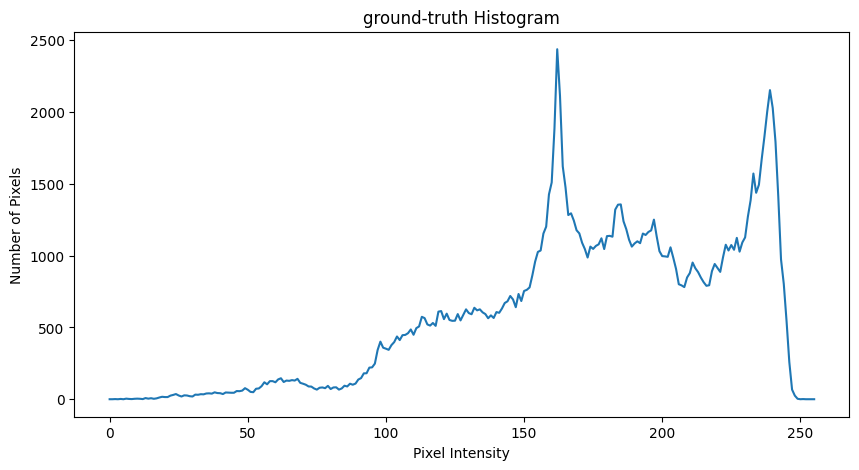

In [17]:
plt.figure(figsize=(10,5))

plt.plot(hist)

plt.title("ground-truth Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

plt.show()

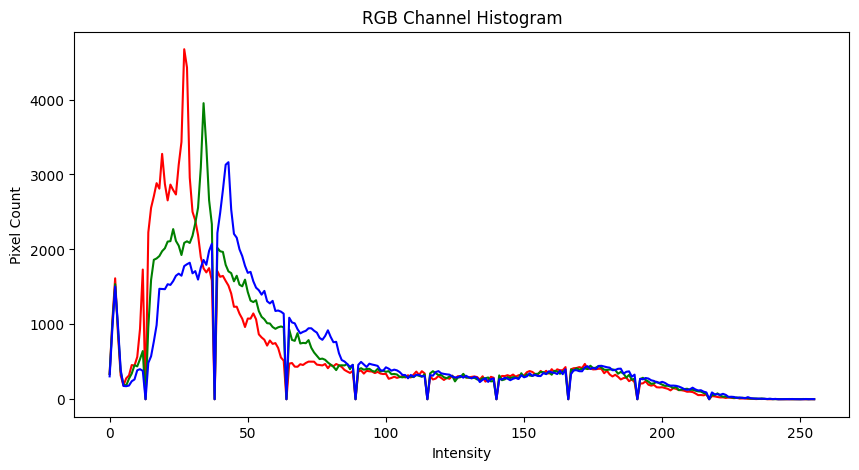

In [18]:
colors = ['r','g','b']

plt.figure(figsize=(10,5))

for i, color in enumerate(colors):

    hist_channel = cv2.calcHist(
        [low_img],
        [i],
        None,
        [256],
        [0,256]
    )

    plt.plot(hist_channel, color=color)

plt.title("RGB Channel Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")

plt.show()

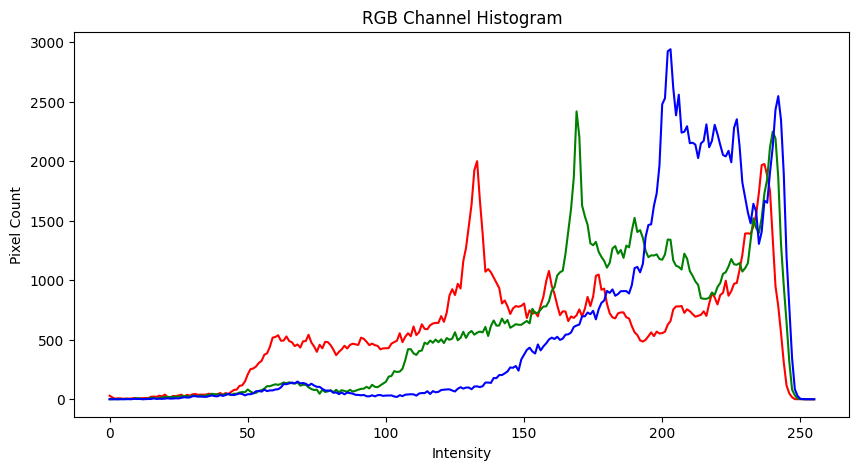

In [19]:
colors = ['r','g','b']

plt.figure(figsize=(10,5))

for i, color in enumerate(colors):

    hist_channel = cv2.calcHist(
        [high_img],
        [i],
        None,
        [256],
        [0,256]
    )

    plt.plot(hist_channel, color=color)

plt.title("RGB Channel Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")

plt.show()

In [20]:
mean_low = np.mean(gray_low)
mean_high = np.mean(gray_high)

print("Low-light mean:", mean_low)
print("Ground truth mean:", mean_high)

Low-light mean: 65.88823784722223
Ground truth mean: 177.99724663628473


In [21]:
std_low = np.std(gray_low)
std_high = np.std(gray_high)

print(std_low)
print(std_high)

53.96919371176755
45.411197354562944


In [22]:
stats = pd.DataFrame({

    "Metric": [
        "Mean Brightness",
        "Std Deviation"
    ],

    "Low-Light": [
        mean_low,
        std_low
    ],

    "Ground Truth": [
        mean_high,
        std_high
    ]

})

stats

,Metric,Low-Light,Ground Truth
0,Mean Brightness,65.888238,177.997247
1,Std Deviation,53.969194,45.411197
